# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFScar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Aprendizado Profundo para Reconhecimento Visual</b></center></font>
  
<font size="3"><center>Prof. Dr. Jurandy Almeida</center></font>

## <center>Projeto</center>

**Nome**: Juan Pedro

**RA**: 823164


#### **1. Configuração Inicial**

Primeiro, vamos executar esta célula para carregar a extensão [autoreload](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload). Isso nos permite editar arquivos de origem `.py` e reimportá-los para o notebook para uma experiência de edição e depuração perfeita.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from tqdm import tqdm
import numpy as np
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import TinyImageNet
from TinyImageNet import denormalize 
from TinyImageNet import prepare_val
from TinyImageNet import load_trained_model
from TinyImageNet import RISE
import eval
from eval import calculate_gini_index, calculate_spatial_coherence
from torchcam.methods import GradCAM
import cv2
from skimage.measure import label
from torchcam.utils import overlay_mask
import traceback
from TinyImageNet import CBAMAnalyzer
from TinyImageNet import force_clear_hooks

In [3]:
data_dir = os.path.join("tiny-imagenet-200")

In [ ]:

# só executar se o dataset ainda não estiver preparado
prepare_val(data_dir)

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform)
val_data = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=4)

In [5]:


model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 200)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


## Treino

In [ ]:
for param in model.layer1.parameters():
    param.requires_grad = False


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
num_epochs = 10

best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc=f"Treino Época {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Treino: Loss={running_loss/len(train_loader):.4f}  Acc={train_acc:.2f}%")

    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    val_acc = 100 * correct / total
    print(f"Val: Loss={val_loss/len(val_loader):.4f}  Acc={val_acc:.2f}%\n")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f"🎉 Nova melhor acurácia, salvando modelo")
        torch.save(model.state_dict(), "resnet50_best.pth")

print("\nTreinamento concluído!")
print(f"Melhor acurácia de validação alcançada: {best_val_acc:.2f}%")

## CARREGAR MODELO NORMAL

In [6]:
path_do_melhor_modelo = "resnet50_tinyimagenet_final.pth" 
model.load_state_dict(torch.load(path_do_melhor_modelo))
print(f"Modelo '{path_do_melhor_modelo}' carregado com sucesso!")
model.eval()

C:\Users\juanp\AppData\Local\Temp\ipykernel_9200\2242699059.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path_do_melhor_modelo))


Modelo 'resnet50_tinyimagenet_final.pth' carregado com sucesso!


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## CARREGAR CBAM

In [ ]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = "resnet50_cbam_best.pth"

if os.path.exists(MODEL_PATH):
    model = load_trained_model(MODEL_PATH, device)
else:
    print(f" Arquivo {MODEL_PATH} não encontrado.")

Carregando arquitetura e pesos de: resnet50_cbam_best.pth


c:\Users\juanp\Projetos\Aprendizado Profundo Para Reconhecimento Visual\Projeto\TinyImageNet\TinyImageNet.py:392: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = 

✅ Modelo carregado com sucesso!


In [ ]:
wnid_to_name = {}
words_file = os.path.join(data_dir, 'words.txt')
with open(words_file, 'r', encoding='utf-8') as f:
    for line in f:
        wnid, name = line.strip().split('\t', 1)
        wnid_to_name[wnid] = name

idx_to_wnid = {v: k for k, v in val_data.class_to_idx.items()}
idx_to_class_name = {k: wnid_to_name[v] for k, v in idx_to_wnid.items()}


## Criação máscaras RISE

In [ ]:
input_size = (224, 224)
mask_save_path = 'masks_tiny_imagenet_4k.npy' 

explainer = RISE(model, input_size, gpu_batch=100) 

N = 4000 
s = 8     
p1 = 0.1 

if not os.path.exists(mask_save_path):
    print(f"Gerando {N} máscaras...")
    explainer.generate_masks(N=N, s=s, p1=p1, savepath=mask_save_path)
else:
    print(f"Carregando máscaras pré-geradas de '{mask_save_path}'...")
    explainer.load_masks(mask_save_path)

print("Máscaras prontas.")

Carregando máscaras pré-geradas de 'masks_tiny_imagenet_4k.npy'...
Máscaras prontas.


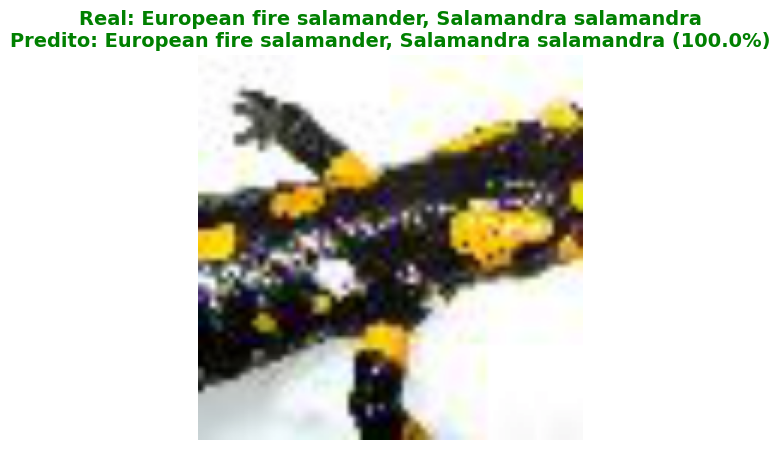

In [ ]:

img_index = 60 


images, labels = next(iter(val_loader))

if img_index >= len(images): img_index = 0
img_tensor = images[img_index].to(device)
real_label_idx = labels[img_index].item()


model.eval()
with torch.no_grad():
    output = model(img_tensor.unsqueeze(0))
    probs = F.softmax(output, dim=1)
    pred_label_idx = probs.argmax(dim=1).item()
    confidence = probs[0, pred_label_idx].item()

real_name = idx_to_class_name.get(real_label_idx, "Desconhecida")
pred_name = idx_to_class_name.get(pred_label_idx, "Desconhecida")

plt.figure(figsize=(5, 5))
plt.imshow(to_pil_image(denormalize(img_tensor.cpu())))


color = 'green' if real_label_idx == pred_label_idx else 'red'
plt.title(f"Real: {real_name}\nPredito: {pred_name} ({confidence:.1%})", 
          color=color, fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

## Avaliação

Imagem selecionada: 3 | Classe: goldfish, Carassius auratus (ID: 0)


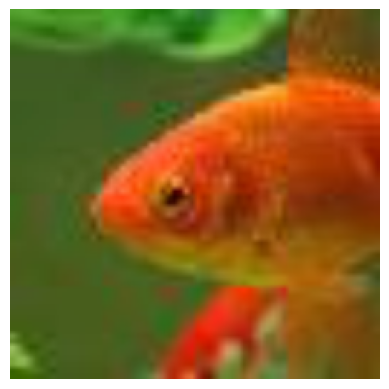

In [ ]:
img_index = 3
images, labels = next(iter(val_loader))

input_tensor = images[img_index].unsqueeze(0).to(device)
target_class = labels[img_index].item()
class_name = idx_to_class_name.get(target_class, "Unknown")

print(f"Imagem selecionada: {img_index} | Classe: {class_name} (ID: {target_class})")

plt.imshow(to_pil_image(TinyImageNet.denormalize(input_tensor.squeeze().cpu())))
plt.axis('off')
plt.show()

In [ ]:

def get_images_for_consistency(dataloader, target_class_idx, count=4):
    found_inputs = []
    found_raws = []
    
    for images, labels in dataloader:
        for i in range(len(labels)):
            if labels[i].item() == target_class_idx:

                found_inputs.append(images[i].unsqueeze(0).to(device))
                if len(found_inputs) >= count:
                    return found_inputs
    return found_inputs

## Grad Cam

Predicted class: 0 (goldfish, Carassius auratus)
Rodando Deletion Test (Removendo 150 px/passo)...
Broke at step: None


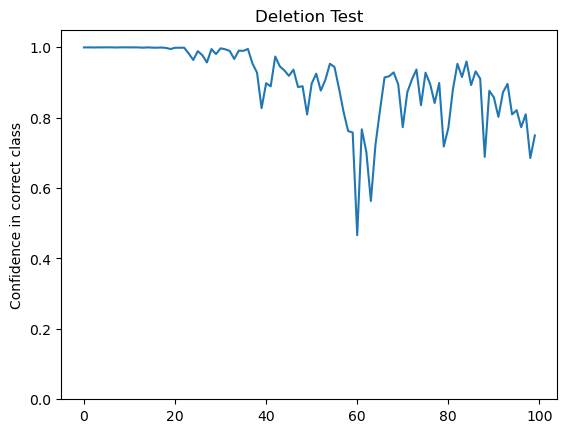

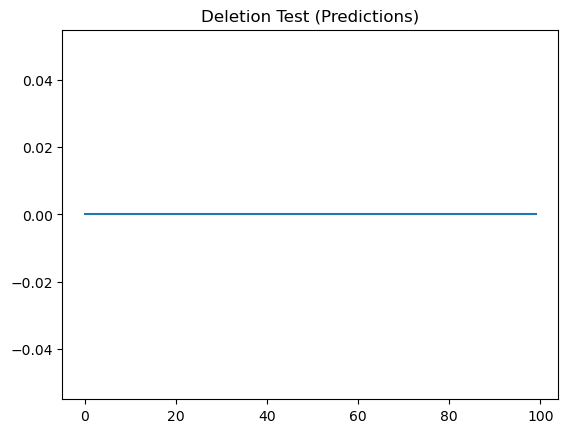

Deletion AUC (Normalizado): 0.8955


C:\Users\juanp\AppData\Local\Temp\ipykernel_35608\3121399713.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(confidences) / len(confidences)


In [ ]:

def force_clear_hooks(model):
    for name, module in model.named_modules():
        if hasattr(module, '_backward_hooks'): module._backward_hooks.clear()
        if hasattr(module, '_forward_hooks'): module._forward_hooks.clear()
        if hasattr(module, '_forward_pre_hooks'): module._forward_pre_hooks.clear()
force_clear_hooks(model)

img_index = 0
images, labels = next(iter(val_loader))
input_tensor = images[img_index].unsqueeze(0).to(device)
target_class = labels[img_index].item()


gradcam = GradCAM(model, target_layer='layer4')
with torch.set_grad_enabled(True):
    preds = model(input_tensor)
    pred_class = torch.argmax(preds, dim=1).item()
    print(f"Predicted class: {pred_class} ({idx_to_class_name.get(pred_class)})")
    
    out = model(input_tensor)
    raw_cam = gradcam(class_idx=pred_class, scores=out)[0]

gradcam.remove_hooks()
force_clear_hooks(model)


H, W = input_tensor.shape[2], input_tensor.shape[3]
if raw_cam.ndim == 2: raw_cam = raw_cam.unsqueeze(0).unsqueeze(0)
elif raw_cam.ndim == 3: raw_cam = raw_cam.unsqueeze(0)

upsampled_cam = F.interpolate(raw_cam, size=(H, W), mode='bilinear', align_corners=False)
heatmap = upsampled_cam.detach().cpu().squeeze().numpy()

heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-7)

pixels_per_step = 150 

print(f"Rodando Deletion Test (Removendo {pixels_per_step} px/passo)...")

confidences, predictions, broke = eval.deletion_test(
    model, 
    input_tensor, 
    heatmap, 
    pred_class, 
    max_steps=100,
    pixels_per_step=pixels_per_step
)
print(f"Broke at step: {broke}")


save_dir = "graficos_deletion"
os.makedirs(save_dir, exist_ok=True)


plt.figure()
plt.plot(confidences)
plt.ylabel('Confidence in correct class')
plt.title('Deletion Test')
plt.ylim(0, 1.05)
plt.savefig(os.path.join(save_dir, f"gradcam_conf_img{img_index}.png"), bbox_inches='tight')
plt.show()

plt.figure()
plt.plot(predictions)
plt.title('Deletion Test (Predictions)')
plt.savefig(os.path.join(save_dir, f"gradcam_pred_img{img_index}.png"), bbox_inches='tight')
plt.show()

auc = np.trapz(confidences) / len(confidences)
print(f"Deletion AUC (Normalizado): {auc:.4f}")

In [ ]:
def gradcam_wrapper(img, tgt=None):
    if tgt is None:
        with torch.no_grad():
            tgt = model(img).argmax(dim=1).item()

    gc = GradCAM(model, target_layer='layer4')

    with torch.set_grad_enabled(True):
        out = model(img)
        raw = gc(class_idx=tgt, scores=out)[0]
    
    gc.remove_hooks()
    
    if raw.ndim == 2: raw = raw.unsqueeze(0).unsqueeze(0)
    elif raw.ndim == 3: raw = raw.unsqueeze(0)
        
    h, w = img.shape[2], img.shape[3]
    upsampled = F.interpolate(raw, size=(h, w), mode='bilinear', align_corners=False)
    cam_np = upsampled.detach().cpu().squeeze().numpy()
    
    return (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-7)

print("Running Robustness Test...")

robustness_score = eval.robustness_test(
    model, 
    'ScoreCAM', # <--- Truque para compatibilidade
    input_tensor, 
    gradcam_wrapper, 
    target=pred_class,
    sigma=0.1,    
    n_perturb=5  
)

print(f"Robustness score: {robustness_score:.4f}")

Running Robustness Test...
Robustness score: 0.9457


In [ ]:



print("Calculando métricas de propriedade...")

gini_index = calculate_gini_index(heatmap)
print(f"Gini Index: {gini_index:.4f}")

coherence = calculate_spatial_coherence(heatmap)
print(f"Spatial Coherence: {coherence:.4f}")

Calculando métricas de propriedade...
Gini Index: 0.6356
Spatial Coherence: 1.0000


Coletando 4 imagens da classe goldfish, Carassius auratus para Grad-CAM...
Gerando heatmaps e overlays...


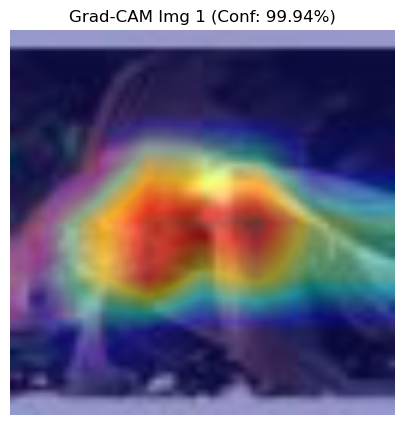

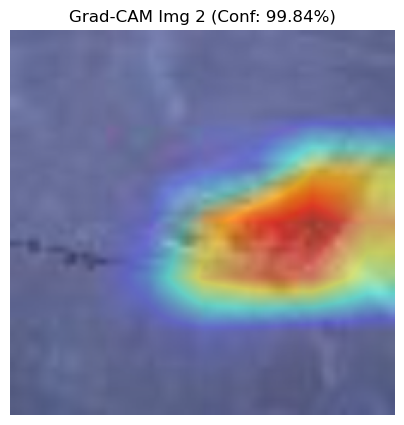

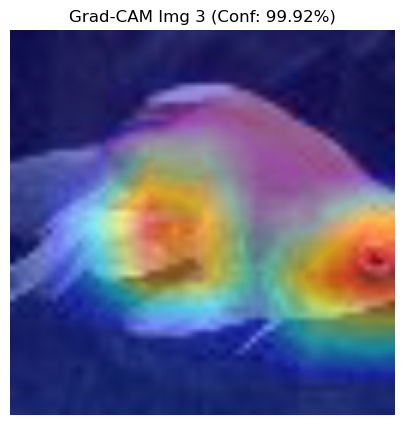

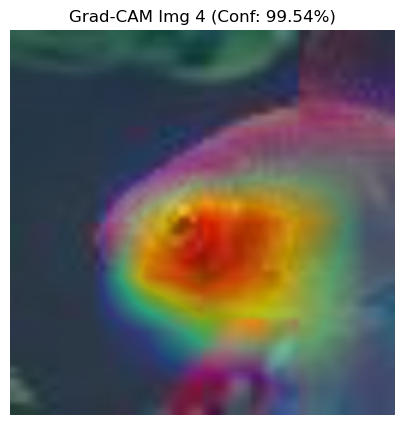


Intra-class Consistency (Grad-CAM): 0.5932


In [ ]:

CLASS_ID = 0 
N_IMAGENS = 4 

print(f"Coletando {N_IMAGENS} imagens da classe {idx_to_class_name.get(CLASS_ID, 'Unknown')} para Grad-CAM...")

def get_images_for_consistency(dataloader, target_class_idx, count=4):
    found_inputs = []
    for images, labels in dataloader:
        for i in range(len(labels)):
            if labels[i].item() == target_class_idx:
                found_inputs.append(images[i].unsqueeze(0).to(device))
                if len(found_inputs) >= count:
                    return found_inputs
    return found_inputs

input_tensors = get_images_for_consistency(val_loader, CLASS_ID, count=N_IMAGENS)

if len(input_tensors) < N_IMAGENS:
    print(f"Aviso: Encontradas apenas {len(input_tensors)} imagens.")

heatmaps_for_metric = []


print("Gerando heatmaps e overlays...")

for i, input_tensor in enumerate(input_tensors):
    force_clear_hooks(model)
    gradcam = GradCAM(model, target_layer='layer4')
    
    with torch.set_grad_enabled(True):
        out = model(input_tensor)
        pred_idx = out.argmax(dim=1).item()
        confidence = F.softmax(out, dim=1)[0, pred_idx].item()
        
        raw_cam = gradcam(class_idx=pred_idx, scores=out)[0]
    
    gradcam.remove_hooks()
    
    if raw_cam.ndim == 2: raw_cam = raw_cam.unsqueeze(0).unsqueeze(0)
    elif raw_cam.ndim == 3: raw_cam = raw_cam.unsqueeze(0)
    
    h, w = input_tensor.shape[2], input_tensor.shape[3]
    upsampled = F.interpolate(raw_cam, size=(h, w), mode='bilinear', align_corners=False)
    cam_2d = upsampled.detach().cpu().squeeze().numpy()

    cam_norm = (cam_2d - cam_2d.min()) / (cam_2d.max() - cam_2d.min() + 1e-7)

    heatmap_color = cv2.applyColorMap(np.uint8(255 * (1 - cam_norm)), cv2.COLORMAP_JET)
    heatmap_float = np.float32(heatmap_color) / 255.0 
    
    raw_img = TinyImageNet.denormalize(input_tensor.squeeze().cpu()).permute(1, 2, 0).numpy()
    
    overlay = heatmap_float * 0.4 + raw_img * 0.6
    overlay = np.clip(overlay, 0, 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(overlay)
    plt.axis('off')
    plt.title(f"Grad-CAM Img {i+1} (Conf: {confidence:.2%})")
    plt.show()
    

    heatmap_final = np.mean(heatmap_float, axis=2)
    heatmaps_for_metric.append(heatmap_final)

consistency = eval.intraclass_consistency(heatmaps_for_metric)
print(f"\nIntra-class Consistency (Grad-CAM): {consistency:.4f}")

### Rise

Predicted class: 0 (goldfish, Carassius auratus)


Processando máscaras: 100%|██████████| 40/40 [00:12<00:00,  3.10it/s]


Rodando Deletion Test (100 steps, -150 px/step)...
Broke at step: 63


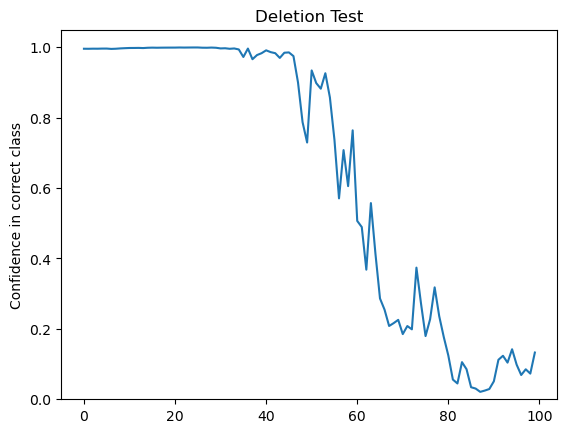

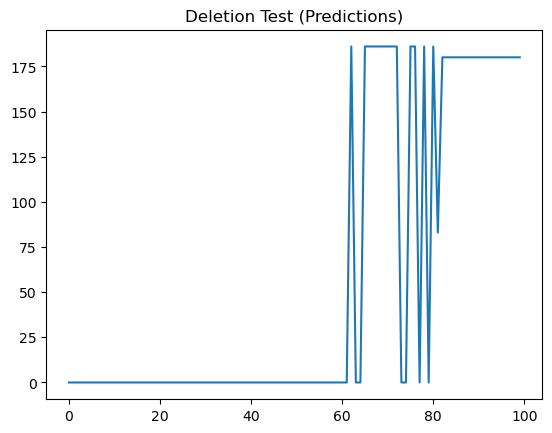

In [ ]:
img_index = 3
images, labels = next(iter(val_loader))
input_tensor = images[img_index].unsqueeze(0).to(device)
target_class = labels[img_index].item()

if 'rise' not in locals():
    print("Carregando RISE...")
    rise = TinyImageNet.RISE(model, (224, 224), gpu_batch=100)
    rise.load_masks('masks_tiny_imagenet_4k.npy')

model.eval()
with torch.no_grad():
    preds = model(input_tensor)
    pred_class = torch.argmax(preds, dim=1).item()
    print(f"Predicted class: {pred_class} ({idx_to_class_name.get(pred_class)})")
    

    saliency = rise(input_tensor)
    sal_map = saliency[pred_class].cpu().numpy()


heatmap = (sal_map - sal_map.min()) / (sal_map.max() - sal_map.min() + 1e-7)

max_steps = 100
pixels_per_step = 150 

print(f"Rodando Deletion Test ({max_steps} steps, -{pixels_per_step} px/step)...")

confidences, predictions, broke = eval.deletion_test(
    model, 
    input_tensor, 
    heatmap, 
    pred_class, 
    max_steps=max_steps,
    pixels_per_step=pixels_per_step
)
print(f"Broke at step: {broke}")


save_dir = "graficos_deletion"
os.makedirs(save_dir, exist_ok=True)


plt.figure()
plt.plot(confidences)
plt.ylabel('Confidence in correct class')
plt.title('Deletion Test')
plt.ylim(0, 1.05)
plt.savefig(os.path.join(save_dir, f"rise_conf_img{img_index}.png"), bbox_inches='tight')
plt.show()

plt.figure()
plt.plot(predictions)
plt.title('Deletion Test (Predictions)')
plt.savefig(os.path.join(save_dir, f"rise_pred_img{img_index}.png"), bbox_inches='tight')
plt.show()

In [ ]:

img_index = 3
images, labels = next(iter(val_loader))
input_tensor = images[img_index].unsqueeze(0).to(device)
target_class = labels[img_index].item()

model.eval()
with torch.no_grad():
    preds = model(input_tensor)
    pred_class = torch.argmax(preds, dim=1).item()
    print(f"Predicted class: {pred_class} ({idx_to_class_name.get(pred_class)})")

if 'rise' not in locals():
    print("Instanciando RISE...")
    rise = TinyImageNet.RISE(model, (224, 224), gpu_batch=100)

    if os.path.exists('masks_tiny_imagenet_4k.npy'):
        rise.load_masks('masks_tiny_imagenet_4k.npy')
    else:
        print("Gerando máscaras...")
        rise.generate_masks(N=4000, s=8, p1=0.1, savepath='masks_tiny_imagenet_4k.npy')

print("Gerando heatmap base...")
with torch.no_grad():
    saliency = rise(input_tensor)
    sal_map = saliency[pred_class].cpu().numpy()

heatmap_norm = (sal_map - sal_map.min()) / (sal_map.max() - sal_map.min() + 1e-7)

print("\n--- Métricas de Propriedade ---")
gini_index = eval.calculate_gini_index(heatmap_norm)
print(f"Gini Index: {gini_index:.4f}")

coherence = eval.calculate_spatial_coherence(heatmap_norm)
print(f"Spatial Coherence: {coherence:.4f}")

print("\n--- Teste de Robustez ---")
print("Rodando Robustness Test...")

def rise_wrapper(img, tgt):
    with torch.no_grad():
        s = rise(img)
    return s[tgt].cpu().numpy()

robustness_score = eval.robustness_test(
    model, 
    'ScoreCAM', # Truque para compatibilidade
    input_tensor, 
    rise_wrapper, 
    target=pred_class, 
    sigma=0.1, 
    n_perturb=5
)

print(f"Robustness score: {robustness_score:.4f}")

Predicted class: 0 (goldfish, Carassius auratus)
Gerando heatmap base...


Processando máscaras: 100%|██████████| 40/40 [00:12<00:00,  3.09it/s]



--- Métricas de Propriedade ---
Gini Index: 0.3710
Spatial Coherence: 0.7793

--- Teste de Robustez ---
Rodando Robustness Test (Isso demora pois o RISE roda muitas vezes)...


Processando máscaras: 100%|██████████| 40/40 [00:12<00:00,  3.12it/s]


Robustness score: 0.9706


Coletando 4 imagens da classe goldfish, Carassius auratus para o RISE...
Gerando mapa 1/4...


Processando máscaras: 100%|██████████| 40/40 [00:13<00:00,  2.92it/s]


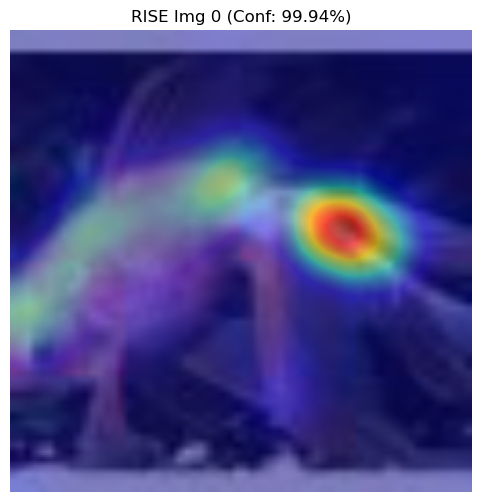

Gerando mapa 2/4...


Processando máscaras: 100%|██████████| 40/40 [00:13<00:00,  2.96it/s]


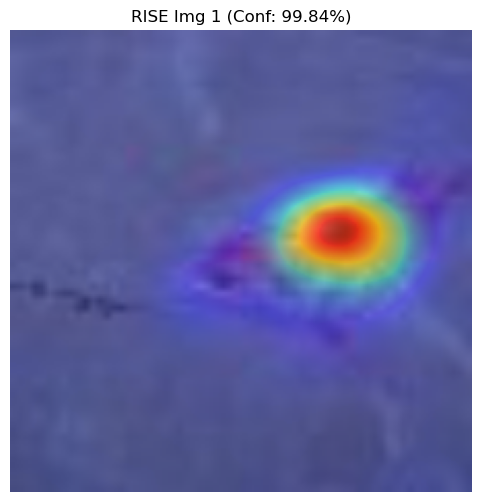

Gerando mapa 3/4...


Processando máscaras: 100%|██████████| 40/40 [00:13<00:00,  2.95it/s]


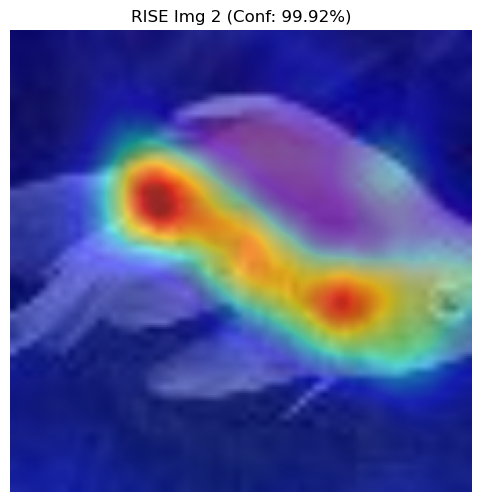

Gerando mapa 4/4...


Processando máscaras: 100%|██████████| 40/40 [00:13<00:00,  2.97it/s]


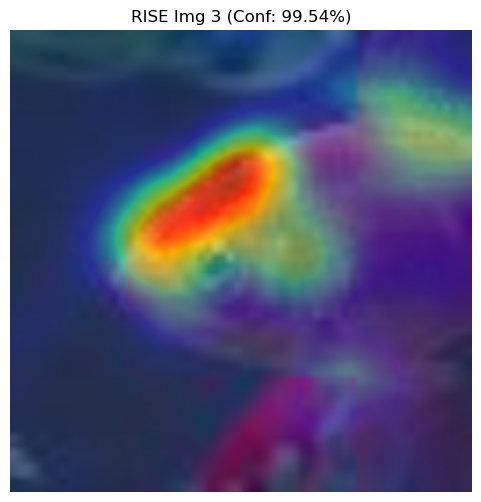

Intra-class Consistency (RISE): 0.4912


In [ ]:
CLASS_ID = 0
N_IMAGENS = 4 

print(f"Coletando {N_IMAGENS} imagens da classe {idx_to_class_name[CLASS_ID]} para o RISE...")
input_tensors = get_images_for_consistency(val_loader, CLASS_ID, count=N_IMAGENS)

if 'rise' not in locals():
    rise = TinyImageNet.RISE(model, (224, 224), gpu_batch=100)
    rise.load_masks('masks_tiny_imagenet_4k.npy')

heatmaps = []

for i, input_tensor in enumerate(input_tensors):

    print(f"Gerando mapa {i+1}/{N_IMAGENS}...")
    with torch.no_grad():
        sal = rise(input_tensor)
    
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    confidence = torch.nn.functional.softmax(output, dim=1)[0, pred_class].item()
    
    sal_map = sal[pred_class].cpu().numpy()

    plt.figure(figsize=(6, 6))

    img_pil = to_pil_image(TinyImageNet.denormalize(input_tensor.squeeze().cpu()))

    sal_map_norm = (sal_map - sal_map.min()) / (sal_map.max() - sal_map.min() + 1e-7)
    heatmap_pil = to_pil_image(sal_map_norm, mode='F')
    overlay = overlay_mask(img_pil, heatmap_pil, alpha=0.5, colormap='jet')
    
    plt.imshow(overlay)
    plt.axis('off')
    plt.title(f"RISE Img {i} (Conf: {confidence:.2%})")
    plt.show()

    heatmaps.append(sal_map)

consistency = eval.intraclass_consistency(heatmaps)
print(f"Intra-class Consistency (RISE): {consistency:.4f}")

## SCORE-CAM

Gerando Score-CAM para classe 1 (European fire salamander, Salamandra salamandra)...
Isso pode demorar um pouco (muitas passagens pelo modelo)...


Score-CAM: 100%|██████████| 32/32 [00:12<00:00,  2.62it/s]


Rodando Deletion Test (Score-CAM)...
Broke at step: 4


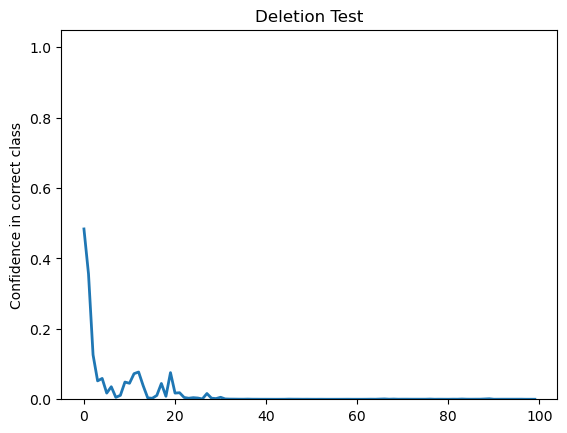

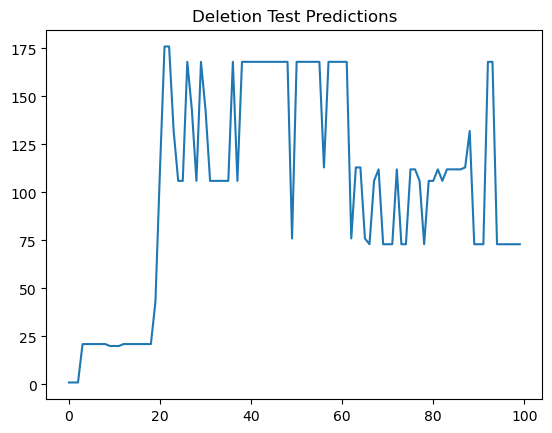

In [ ]:
img_index = 62
images, labels = next(iter(val_loader))
input_tensor = images[img_index].unsqueeze(0).to(device)
target_class = labels[img_index].item() 

model.eval()
TinyImageNet.force_clear_hooks(model) 

scorecam = TinyImageNet.ScoreCAM(model, target_layer=model.layer4)

print(f"Gerando Score-CAM para classe {target_class} ({idx_to_class_name.get(target_class)})...")

heatmap = scorecam.generate(input_tensor, target_class=target_class, batch_size=64)

scorecam.remove_hooks() 

heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-7)

pixels_per_step = 150 
print(f"Rodando Deletion Test (Score-CAM)...")

confidences, predictions, broke = eval.deletion_test(
    model, 
    input_tensor, 
    heatmap, 
    target_class, 
    max_steps=100, 
    pixels_per_step=pixels_per_step
)
print(f"Broke at step: {broke}")

save_dir = "graficos_deletion"
os.makedirs(save_dir, exist_ok=True)


plt.figure()
plt.plot(confidences, color='#1f77b4', linewidth=2)
plt.ylabel('Confidence in correct class')
plt.title('Deletion Test')
plt.ylim(0, 1.05)
plt.savefig(os.path.join(save_dir, f"scorecam_conf_img{img_index}.png"), bbox_inches='tight')
plt.show()

plt.figure()
plt.plot(predictions)
plt.title('Deletion Test Predictions')
plt.savefig(os.path.join(save_dir, f"scorecam_pred_img{img_index}.png"), bbox_inches='tight')
plt.show()


In [ ]:

img_index = 62
images, labels = next(iter(val_loader))
input_tensor = images[img_index].unsqueeze(0).to(device)
target_class = labels[img_index].item()

model.eval()
TinyImageNet.force_clear_hooks(model)

print(f"Avaliando Score-CAM para classe: {idx_to_class_name.get(target_class)}")

print("Gerando mapa base...")
scorecam = TinyImageNet.ScoreCAM(model, target_layer=model.layer4)

heatmap = scorecam.generate(input_tensor, target_class=target_class, batch_size=64)
scorecam.remove_hooks()

heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-7)

print("\n--- Métricas de Propriedade ---")
gini_index = eval.calculate_gini_index(heatmap)
print(f"Gini Index: {gini_index:.4f}")

coherence = eval.calculate_spatial_coherence(heatmap)
print(f"Spatial Coherence: {coherence:.4f}")

print("\n--- Teste de Robustez ---")
print("Rodando Robustness Test...")

def scorecam_wrapper(img, tgt):
    sc = TinyImageNet.ScoreCAM(model, target_layer=model.layer4)
    hm = sc.generate(img, target_class=tgt, batch_size=64)
    sc.remove_hooks()
    return hm

try:
    robustness_score = eval.robustness_test(
        model=model, 
        model_name='ScoreCAM',
        img_tensor=input_tensor, 
        explain_fn=scorecam_wrapper,
        target=target_class, 
        sigma=0.1, 
        n_perturb=5 
    )
    print(f"Robustness score: {robustness_score:.4f}")
    
except Exception as e:
    print(f"Erro no teste de robustez: {e}")

Avaliando Score-CAM para classe: European fire salamander, Salamandra salamandra
Gerando mapa base (pode demorar)...


Score-CAM: 100%|██████████| 32/32 [00:12<00:00,  2.57it/s]



--- Métricas de Propriedade ---
Gini Index: 0.5704
Spatial Coherence: 1.0000

--- Teste de Robustez ---
Rodando Robustness Test (Isso vai demorar, tenha paciência)...


Score-CAM: 100%|██████████| 32/32 [00:12<00:00,  2.59it/s]


Robustness score: 0.9441


Coletando 4 imagens da classe European fire salamander, Salamandra salamandra para Score-CAM...
Gerando heatmaps Score-CAM (Isso vai demorar alguns minutos)...
  Processando imagem 1/4...


Score-CAM: 100%|██████████| 32/32 [00:12<00:00,  2.58it/s]


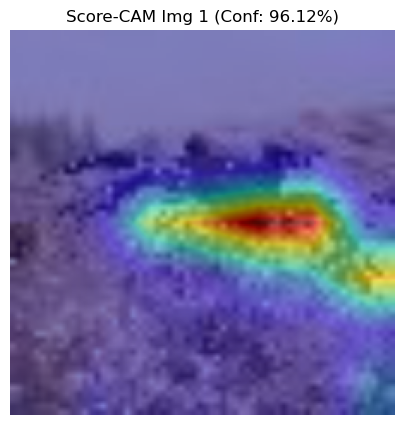

  Processando imagem 2/4...


Score-CAM: 100%|██████████| 32/32 [00:12<00:00,  2.61it/s]


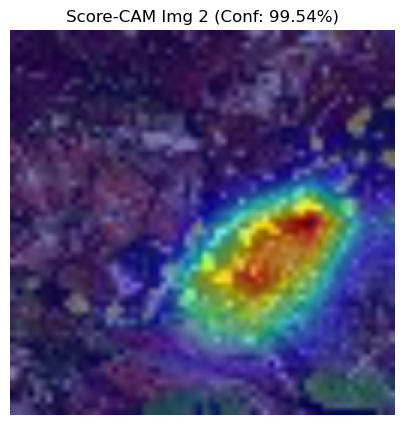

  Processando imagem 3/4...


Score-CAM: 100%|██████████| 32/32 [00:12<00:00,  2.60it/s]


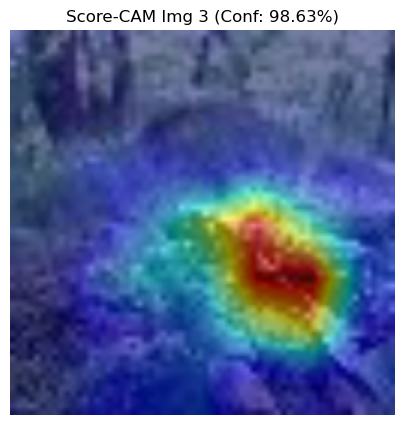

  Processando imagem 4/4...


Score-CAM: 100%|██████████| 32/32 [00:12<00:00,  2.60it/s]


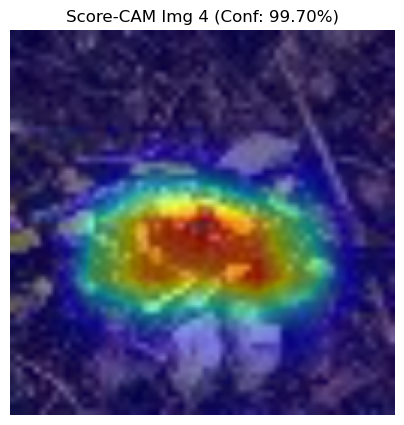


Intra-class Consistency (Score-CAM): 0.7997


In [ ]:

CLASS_ID = 1 
N_IMAGENS = 4 

print(f"Coletando {N_IMAGENS} imagens da classe {idx_to_class_name.get(CLASS_ID, 'Unknown')} para Score-CAM...")

def get_images_for_consistency(dataloader, target_class_idx, count=4):
    found_inputs = []
    for images, labels in dataloader:
        for i in range(len(labels)):
            if labels[i].item() == target_class_idx:
                found_inputs.append(images[i].unsqueeze(0).to(device))
                if len(found_inputs) >= count:
                    return found_inputs
    return found_inputs

input_tensors = get_images_for_consistency(val_loader, CLASS_ID, count=N_IMAGENS)

if len(input_tensors) < N_IMAGENS:
    print(f"Aviso: Encontradas apenas {len(input_tensors)} imagens.")

heatmaps_for_metric = [] 

def force_clear_hooks(model):
    for name, module in model.named_modules():
        if hasattr(module, '_backward_hooks'): module._backward_hooks.clear()
        if hasattr(module, '_forward_hooks'): module._forward_hooks.clear()
        if hasattr(module, '_forward_pre_hooks'): module._forward_pre_hooks.clear()

print("Gerando heatmaps Score-CAM...")

for i, input_tensor in enumerate(input_tensors):
    print(f"  Processando imagem {i+1}/{N_IMAGENS}...")
    
    force_clear_hooks(model)
    scorecam = TinyImageNet.ScoreCAM(model, target_layer=model.layer4)

    model.eval()
    with torch.no_grad():
        out = model(input_tensor)
        pred_idx = out.argmax(dim=1).item()
        confidence = F.softmax(out, dim=1)[0, pred_idx].item()

    heatmap_2d = scorecam.generate(input_tensor, target_class=CLASS_ID, batch_size=64)
    
    scorecam.remove_hooks()
 
    heatmap_norm = (heatmap_2d - heatmap_2d.min()) / (heatmap_2d.max() - heatmap_2d.min() + 1e-7)
    
    img_pil = to_pil_image(TinyImageNet.denormalize(input_tensor.squeeze().cpu()))

    heatmap_pil = to_pil_image(heatmap_norm, mode='F')
    overlay = overlay_mask(img_pil, heatmap_pil, alpha=0.5, colormap='jet')
    
    plt.figure(figsize=(5, 5))
    plt.imshow(overlay)
    plt.axis('off')
    plt.title(f"Score-CAM Img {i+1} (Conf: {confidence:.2%})")
    plt.show()
 
    heatmaps_for_metric.append(heatmap_norm)

consistency = eval.intraclass_consistency(heatmaps_for_metric)
print(f"\nIntra-class Consistency (Score-CAM): {consistency:.4f}")

## Integrated Gradients

Predicted class: 1
Broke at step: 1


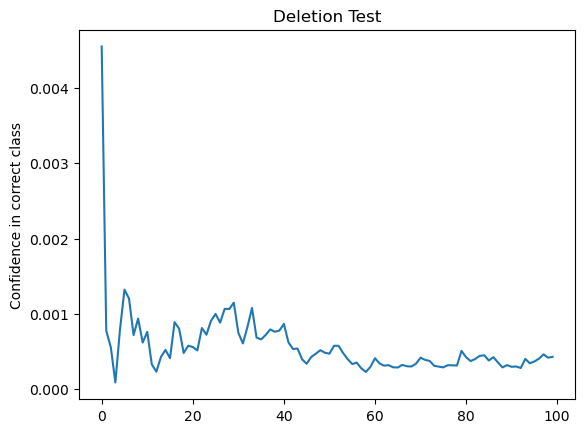

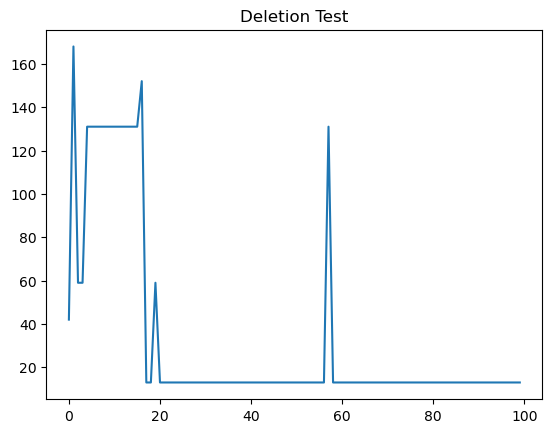

In [ ]:
img_index = 62
images, labels = next(iter(val_loader))
input_tensor = images[img_index].unsqueeze(0).to(device)
target_class = labels[img_index].item()

ig = TinyImageNet.IntegratedGradients(model)
model.eval()

with torch.set_grad_enabled(True):
    preds = model(input_tensor)
    pred_class = torch.argmax(preds, dim=1).item()
    print(f"Predicted class: {pred_class}")
    
    attributions = ig.generate(input_tensor, target_class=pred_class, steps=50)

attr_np = attributions.squeeze(0).cpu().permute(1, 2, 0).numpy()

sal_map = np.mean(np.abs(attr_np), axis=2)

pixels_per_step = 150 

confidences, predictions, broke = eval.deletion_test(
    model, 
    input_tensor, 
    sal_map, 
    pred_class, 
    max_steps=100, 
    pixels_per_step=pixels_per_step
)
print(f"Broke at step: {broke}")

save_dir = "graficos_deletion"
os.makedirs(save_dir, exist_ok=True)

plt.figure()
plt.plot(confidences)
plt.ylabel('Confidence in correct class')
plt.title('Deletion Test')
plt.savefig(os.path.join(save_dir, f"ig_conf_img{img_index}.png"), bbox_inches='tight')
plt.show()

plt.figure()
plt.plot(predictions)
plt.title('Deletion Test')
plt.savefig(os.path.join(save_dir, f"ig_pred_img{img_index}.png"), bbox_inches='tight')
plt.show()

In [ ]:

img_index = 62
images, labels = next(iter(val_loader))
input_tensor = images[img_index].unsqueeze(0).to(device)
target_class = labels[img_index].item()

model.eval()
TinyImageNet.force_clear_hooks(model)

print(f"Avaliando IG para classe: {idx_to_class_name.get(target_class)}")

ig = TinyImageNet.IntegratedGradients(model)

with torch.set_grad_enabled(True):
    attributions = ig.generate(input_tensor, target_class=target_class, steps=50)

attr_np = attributions.squeeze(0).cpu().detach().numpy()
heatmap_base = np.mean(np.abs(attr_np), axis=0)

vmax = np.percentile(heatmap_base, 99)
vmin = np.min(heatmap_base)
heatmap_norm = np.clip(heatmap_base, vmin, vmax)
heatmap_norm = (heatmap_norm - vmin) / (vmax - vmin + 1e-7)

print("\n--- Métricas de Propriedade ---")
gini_index = eval.calculate_gini_index(heatmap_norm)
print(f"Gini Index: {gini_index:.4f}")

coherence = eval.calculate_spatial_coherence(heatmap_norm)
print(f"Spatial Coherence: {coherence:.4f}")

print("\n--- Teste de Robustez ---")
print("Rodando Robustness Test...")

def ig_wrapper(img, tgt):

    i_g = TinyImageNet.IntegratedGradients(model)

    with torch.set_grad_enabled(True):
        attrs = i_g.generate(img, target_class=tgt, steps=30)

    am = attrs.squeeze(0).cpu().detach().numpy()
    am_mean = np.mean(np.abs(am), axis=0)
    
    v = np.percentile(am_mean, 99)
    mn = np.min(am_mean)
    am_clip = np.clip(am_mean, mn, v)
    return (am_clip - mn) / (v - mn + 1e-7)

try:
    robustness_score = eval.robustness_test(
        model, 
        'ScoreCAM', # Truque de compatibilidade
        input_tensor, 
        ig_wrapper, 
        target=target_class, 
        sigma=0.1,    
        n_perturb=5  
    )
    print(f"Robustness score: {robustness_score:.4f}")
    
except Exception as e:
    print(f"Erro no teste de robustez: {e}")

Avaliando IG para classe: European fire salamander, Salamandra salamandra

--- Métricas de Propriedade ---
Gini Index: 0.5785
Spatial Coherence: 0.0282

--- Teste de Robustez ---
Rodando Robustness Test...
Robustness score: 0.4108


Coletando 4 imagens da classe European fire salamander, Salamandra salamandra para IG...
Gerando heatmaps IG e overlays...


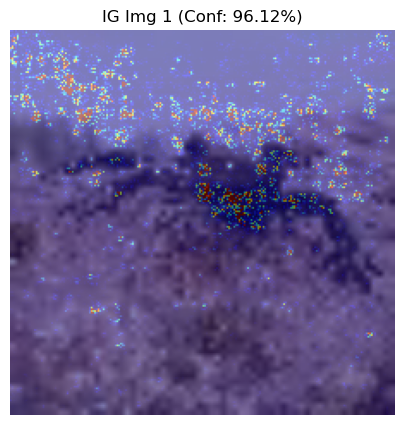

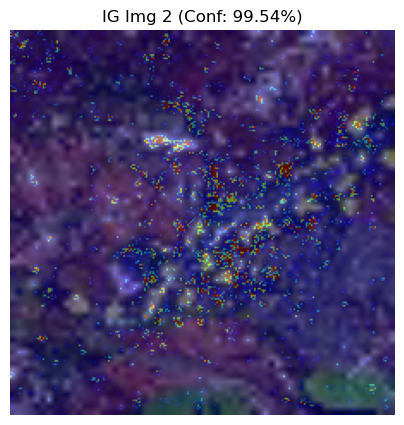

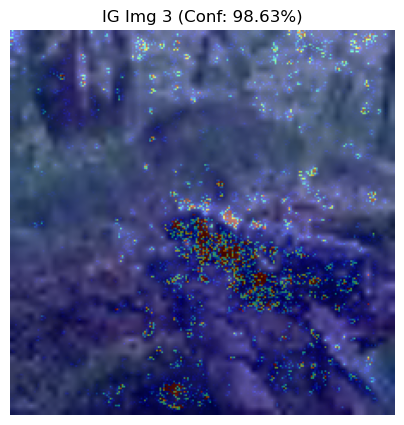

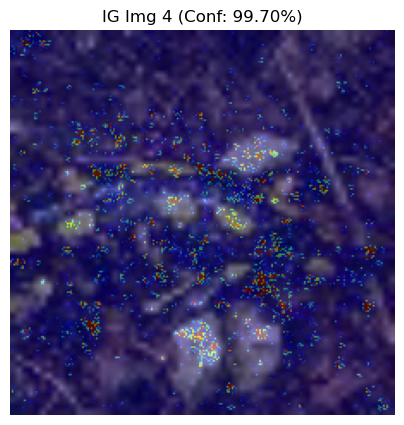


Intra-class Consistency (IG): 0.1180


In [ ]:

CLASS_ID = 1 
N_IMAGENS = 4 

print(f"Coletando {N_IMAGENS} imagens da classe {idx_to_class_name.get(CLASS_ID, 'Unknown')} para IG...")

def get_images_for_consistency(dataloader, target_class_idx, count=4):
    found_inputs = []
    for images, labels in dataloader:
        for i in range(len(labels)):
            if labels[i].item() == target_class_idx:
                found_inputs.append(images[i].unsqueeze(0).to(device))
                if len(found_inputs) >= count:
                    return found_inputs
    return found_inputs

input_tensors = get_images_for_consistency(val_loader, CLASS_ID, count=N_IMAGENS)

if len(input_tensors) < N_IMAGENS:
    print(f"Aviso: Encontradas apenas {len(input_tensors)} imagens.")

heatmaps_for_metric = [] 

ig = TinyImageNet.IntegratedGradients(model)

print("Gerando heatmaps IG e overlays...")

for i, input_tensor in enumerate(input_tensors):
    TinyImageNet.force_clear_hooks(model)

    model.eval()
    with torch.no_grad():
        out = model(input_tensor)
        pred_idx = out.argmax(dim=1).item()
        confidence = F.softmax(out, dim=1)[0, pred_idx].item()
    

    with torch.set_grad_enabled(True):
        attributions = ig.generate(input_tensor, target_class=pred_idx, steps=50)
    
    attr_np = attributions.squeeze(0).cpu().detach().numpy()
    heatmap_2d = np.mean(np.abs(attr_np), axis=0)
    
    vmax = np.percentile(heatmap_2d, 99)
    heatmap_norm = np.clip(heatmap_2d, 0, vmax)
    heatmap_norm = (heatmap_norm - heatmap_norm.min()) / (heatmap_norm.max() - heatmap_norm.min() + 1e-7)
    
    img_pil = to_pil_image(TinyImageNet.denormalize(input_tensor.detach().cpu().squeeze()))
    
    heatmap_pil = to_pil_image(heatmap_norm, mode='F')
    overlay = overlay_mask(img_pil, heatmap_pil, alpha=0.5, colormap='jet')
    
    plt.figure(figsize=(5, 5))
    plt.imshow(overlay)
    plt.axis('off')
    plt.title(f"IG Img {i+1} (Conf: {confidence:.2%})")
    plt.show()
    
    heatmaps_for_metric.append(heatmap_norm)

consistency = eval.intraclass_consistency(heatmaps_for_metric)
print(f"\nIntra-class Consistency (IG): {consistency:.4f}")

## CBAM

In [ ]:


analyzer = CBAMAnalyzer(model, device)
os.makedirs("graficos_cbam", exist_ok=True)

In [ ]:

img_index = 62
images, labels = next(iter(val_loader)) 

input_tensor = images[img_index].unsqueeze(0).to(device)
target_class = labels[img_index].item()

class_name = idx_to_class_name.get(target_class, str(target_class)) if 'idx_to_class_name' in globals() else str(target_class)

print(f"Imagem selecionada: Índice {img_index}, Classe: {class_name}")


Imagem selecionada: Índice 62, Classe: European fire salamander, Salamandra salamandra


Gerando mapa CBAM...


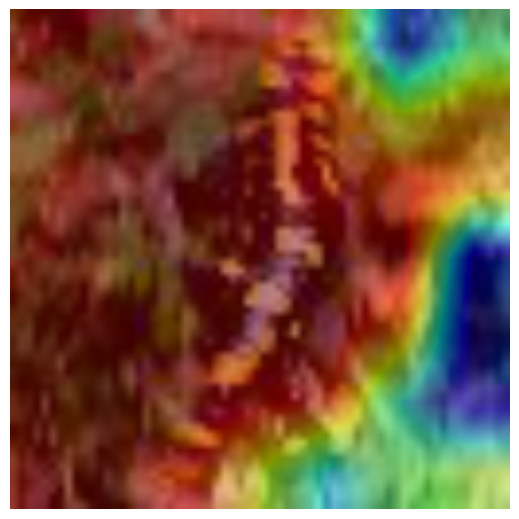

In [ ]:
print("Gerando mapa CBAM...")
heatmap = analyzer.get_attention_map(input_tensor.squeeze(0))

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

img_vis = inv_normalize(input_tensor.squeeze(0).cpu()).permute(1, 2, 0).numpy()
img_vis = np.clip(img_vis, 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(img_vis)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.axis('off')
plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
plt.margins(0,0)
plt.show()


--- Rodando Deletion Test (CBAM) ---
Quebrou (predição mudou) no passo: 23


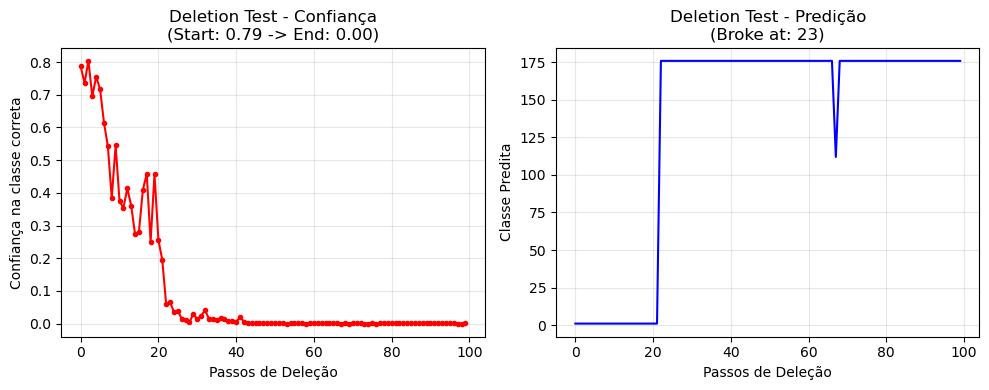

Deletion AUC: 0.1077 (Menor é melhor)


C:\Users\juanp\AppData\Local\Temp\ipykernel_31696\3277060694.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(confidences) / len(confidences)


In [ ]:

heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

print("\n--- Rodando Deletion Test (CBAM) ---")

pixels_per_step = 150
max_steps = 100

confidences, predictions, broke = eval.deletion_test(
    model, 
    input_tensor, 
    heatmap_norm, 
    target_class, 
    max_steps=max_steps, 
    pixels_per_step=pixels_per_step
)

print(f"Quebrou (predição mudou) no passo: {broke}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(confidences, color='red', marker='.')
plt.ylabel('Confiança na classe correta')
plt.xlabel('Passos de Deleção')
plt.title(f'Deletion Test - Confiança\n(Start: {confidences[0]:.2f} -> End: {confidences[-1]:.2f})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(predictions, color='blue')
plt.ylabel('Classe Predita')
plt.xlabel('Passos de Deleção')
plt.title(f'Deletion Test - Predição\n(Broke at: {broke})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("graficos_cbam", f"cbam_deletion_img{img_index}.png"))
plt.show()

auc = np.trapz(confidences) / len(confidences)
print(f"Deletion AUC: {auc:.4f} (Menor é melhor)")

In [ ]:


print("\n--- Métricas de Propriedade ---")

gini_index = eval.calculate_gini_index(heatmap_norm)
print(f"Gini Index: {gini_index:.4f}")

coherence = eval.calculate_spatial_coherence(heatmap_norm)
print(f"Spatial Coherence: {coherence:.4f}")

print("\n--- Teste de Robustez ---")


def cbam_wrapper(img_4d_tensor):
    return analyzer.get_attention_map(img_4d_tensor.squeeze(0))

try:
    robustness_score = eval.robustness_test(
        model, 
        'GradCAM',    
        input_tensor, 
        cbam_wrapper,  
        target=target_class, 
        sigma=0.1,     
        n_perturb=5   
    )
    
    print(f"Robustness Score: {robustness_score:.4f}")
    
except Exception as e:
    print(f"Erro no teste de robustez: {e}")
    traceback.print_exc()


--- Métricas de Propriedade ---
Gini Index: 0.1550 (Maior = mais focado)
Spatial Coherence: 0.9866 (Menor = mais coerente/suave)

--- Teste de Robustez ---
Robustness Score (Correlação Média): 0.8733
Interpretação: Próximo de 1.0 indica que a explicação é estável mesmo com ruído na imagem.


Imagem selecionada: Índice 62, Classe: European fire salamander, Salamandra salamandra
Gerando mapa CBAM...

--- Teste de Consistência Intra-Classe ---
Coletando 4 imagens da classe European fire salamander, Salamandra salamandra...
Gerando mapas para as amostras...


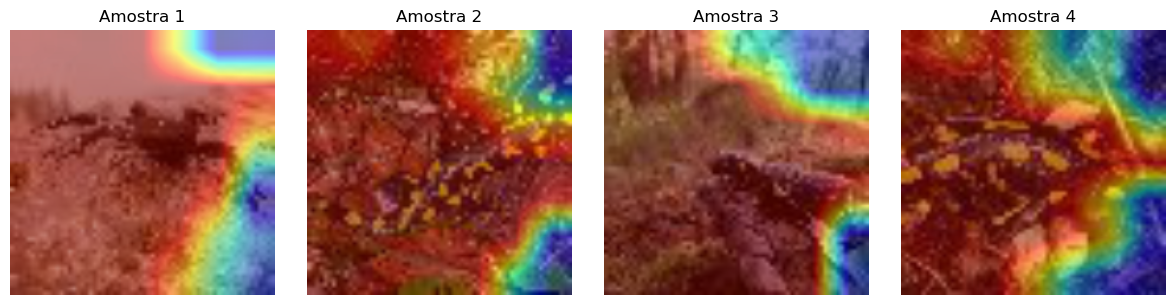


>>> Consistência Intra-classe (CBAM): 0.7984
Interpretação: Quanto mais próximo de 1.0, mais consistente é a explicação entre imagens da mesma classe.


In [ ]:
img_index = 62 
images, labels = next(iter(val_loader)) 

input_tensor = images[img_index].unsqueeze(0).to(device) 
target_class = labels[img_index].item()

class_name = idx_to_class_name.get(target_class, str(target_class)) if 'idx_to_class_name' in globals() else str(target_class)

print(f"Imagem selecionada: Índice {img_index}, Classe: {class_name}")


print("Gerando mapa CBAM...")
heatmap = analyzer.get_attention_map(input_tensor.squeeze(0))

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
img_vis = inv_normalize(input_tensor.squeeze(0).cpu()).permute(1, 2, 0).numpy()
img_vis = np.clip(img_vis, 0, 1)

heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

print("\n--- Teste de Consistência Intra-Classe ---")

def get_class_samples(dataloader, class_id, n=5):
    found = []
    for imgs, lbls in dataloader:
        for i in range(len(lbls)):
            if lbls[i].item() == class_id:
                found.append(imgs[i].unsqueeze(0).to(device))
                if len(found) == n: 
                    return found
    return found

CLASS_ID = target_class 
N_SAMPLES = 4

class_name_str = idx_to_class_name.get(CLASS_ID, str(CLASS_ID)) if 'idx_to_class_name' in globals() else str(CLASS_ID)
print(f"Coletando {N_SAMPLES} imagens da classe {class_name_str}...")

samples = get_class_samples(val_loader, CLASS_ID, n=N_SAMPLES)

if len(samples) < 2:
    print("Não foi possível encontrar imagens suficientes para o teste de consistência.")
else:
    heatmaps_list = []

    plt.figure(figsize=(15, 3))
    
    print("Gerando mapas para as amostras...")
    for i, img_tensor in enumerate(samples):
        heatmap = analyzer.get_attention_map(img_tensor.squeeze(0))
        heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        heatmaps_list.append(heatmap_norm)

        if i < 5:
            inv_normalize = transforms.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225]
            )
            img_vis = inv_normalize(img_tensor.squeeze(0).cpu()).permute(1, 2, 0).numpy()
            img_vis = np.clip(img_vis, 0, 1)
            
            plt.subplot(1, 5, i+1)
            plt.imshow(img_vis)
            plt.imshow(heatmap_norm, cmap='jet', alpha=0.5)
            plt.title(f"Amostra {i+1}")
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

    consistency_score = eval.intraclass_consistency(heatmaps_list)
    print(f"\n>>> Consistência Intra-classe (CBAM): {consistency_score:.4f}")

## Fusão

Gerando Score-CAM...


Score-CAM: 100%|██████████| 32/32 [00:12<00:00,  2.62it/s]


Gerando Integrated Gradients...


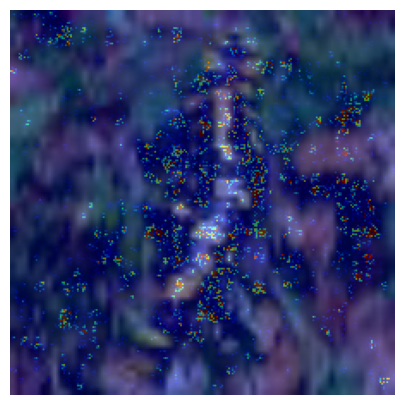

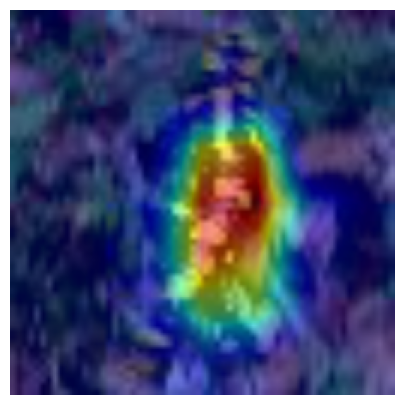

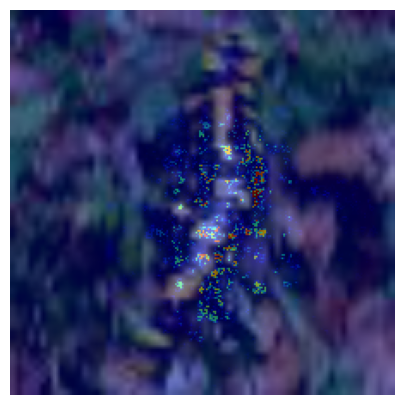

In [ ]:

def generate_hybrid_explanation(map1, map2, method="multiply"):

    if method == "multiply":
        hybrid = map1 * map2
    elif method == "average":
        hybrid = (map1 + map2) / 2
    
    hybrid = (hybrid - hybrid.min()) / (hybrid.max() - hybrid.min() + 1e-7)
    return hybrid

img_index = 62 
images, labels = next(iter(val_loader))
input_tensor = images[img_index].unsqueeze(0).to(device)
target_class = labels[img_index].item()
class_name = idx_to_class_name.get(target_class, "Unknown")


print("Gerando Score-CAM...")
sc = TinyImageNet.ScoreCAM(model, target_layer=model.layer4)
sc_map = sc.generate(input_tensor, target_class=target_class, batch_size=64)
sc.remove_hooks()
sc_map = (sc_map - sc_map.min()) / (sc_map.max() - sc_map.min() + 1e-7)

print("Gerando Integrated Gradients...")
ig = TinyImageNet.IntegratedGradients(model)
with torch.set_grad_enabled(True):
    ig_attr = ig.generate(input_tensor, target_class=target_class, steps=50)

ig_raw = np.abs(ig_attr.squeeze(0).cpu().detach().numpy()).mean(axis=0)

v = np.percentile(ig_raw, 99)
ig_map = np.clip(ig_raw, 0, v)
ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min() + 1e-7)

hybrid_map = generate_hybrid_explanation(sc_map, ig_map, method="multiply")

img_pil = to_pil_image(TinyImageNet.denormalize(input_tensor.squeeze().cpu()))

plt.figure(figsize=(5, 5))
plt.imshow(overlay_mask(img_pil, to_pil_image(ig_map, mode='F'), alpha=0.5, colormap='jet'))
plt.axis('off')
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(overlay_mask(img_pil, to_pil_image(sc_map, mode='F'), alpha=0.5, colormap='jet'))
plt.axis('off')
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(overlay_mask(img_pil, to_pil_image(hybrid_map, mode='F'), alpha=0.5, colormap='jet'))
plt.axis('off')
plt.show()

Rodando Deletion Test no Método Híbrido...
Broke at step: 1
Deletion AUC: 0.0005


C:\Users\juanp\AppData\Local\Temp\ipykernel_23512\2592722199.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(confidences) / len(confidences)


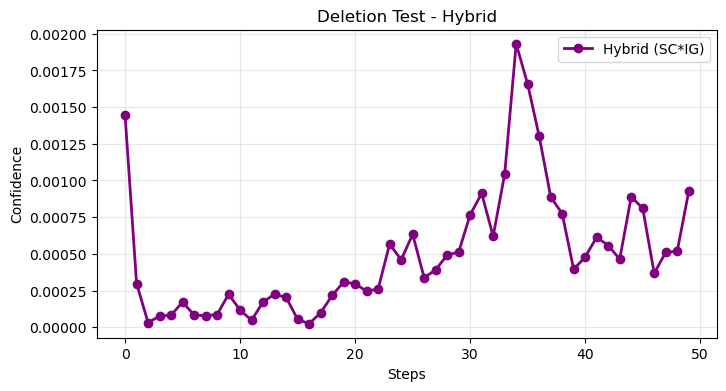

In [ ]:

print(f"Rodando Deletion Test no Método Híbrido...")

pixels_per_step = 150 
max_steps = 50

confidences, predictions, broke = eval.deletion_test(
    model, 
    input_tensor, 
    hybrid_map, 
    target_class, 
    max_steps=max_steps, 
    pixels_per_step=pixels_per_step
)

print(f"Broke at step: {broke}")
auc = np.trapz(confidences) / len(confidences)
print(f"Deletion AUC: {auc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(confidences, marker='o', color='purple', linewidth=2, label='Hybrid (SC*IG)')
plt.title('Deletion Test - Hybrid')
plt.ylabel('Confidence'); plt.xlabel('Steps')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

gini = eval.calculate_gini_index(hybrid_map)
coherence = eval.calculate_spatial_coherence(hybrid_map)

print(f"Gini Index: {gini:.4f}")
print(f"Spatial Coherence: {coherence:.4f}")

print("Calculando Robustez do Híbrido (Pode demorar)...")

def hybrid_wrapper(img, tgt):
   
    sc = TinyImageNet.ScoreCAM(model, target_layer=model.layer4)
    sc_m = sc.generate(img, tgt, batch_size=64)
    sc.remove_hooks()
    sc_m = (sc_m - sc_m.min()) / (sc_m.max() - sc_m.min() + 1e-7)
    
   
    ig = TinyImageNet.IntegratedGradients(model)
    with torch.set_grad_enabled(True):
        attrs = ig.generate(img, tgt, steps=30)
    ig_m = np.abs(attrs.squeeze(0).cpu().detach().numpy()).mean(axis=0)
    v = np.percentile(ig_m, 99)
    ig_m = np.clip(ig_m, 0, v)
    ig_m = (ig_m - ig_m.min()) / (ig_m.max() - ig_m.min() + 1e-7)
    
    
    hyb = sc_m * ig_m
    return (hyb - hyb.min()) / (hyb.max() - hyb.min() + 1e-7)

try:
    rob_score = eval.robustness_test(
        model, 'ScoreCAM', input_tensor, hybrid_wrapper, 
        target=target_class, sigma=0.1, n_perturb=5
    )
    print(f"Robustness Score: {rob_score:.4f}")
except Exception as e:
    print(f"Erro: {e}")

Gini Index: 0.7870
Spatial Coherence: 0.0707
Calculando Robustez do Híbrido (Pode demorar)...


Score-CAM: 100%|██████████| 32/32 [01:55<00:00,  3.60s/it]


Robustness Score: 0.6175


Coletando 4 imagens da classe European fire salamander, Salamandra salamandra para Fusão...
Processando fusão para consistência...


Score-CAM: 100%|██████████| 32/32 [01:52<00:00,  3.52s/it]


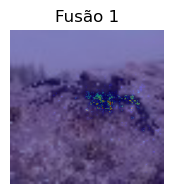

Score-CAM: 100%|██████████| 32/32 [01:44<00:00,  3.28s/it]


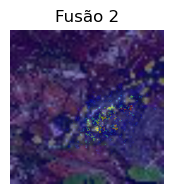

Score-CAM: 100%|██████████| 32/32 [01:42<00:00,  3.19s/it]


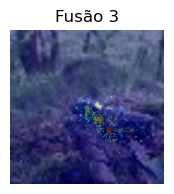

Score-CAM: 100%|██████████| 32/32 [01:45<00:00,  3.30s/it]


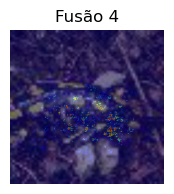


>>> Consistência Intra-classe (Híbrido): 0.3310


In [ ]:

CLASS_ID = 1
N_SAMPLES = 4

print(f"Coletando {N_SAMPLES} imagens da classe {idx_to_class_name.get(CLASS_ID, 'Unknown')} para Fusão...")

def get_class_samples(dataloader, class_id, n=5):
    found = []
    for imgs, lbls in dataloader:
        for i in range(len(lbls)):
            if lbls[i].item() == class_id:
                found.append(imgs[i].unsqueeze(0).to(device))
                if len(found) == n: return found
    return found

samples = get_class_samples(val_loader, CLASS_ID, n=N_SAMPLES)

heatmaps_list = []

ig = TinyImageNet.IntegratedGradients(model)

print("Processando fusão para consistência...")

for i, img in enumerate(samples):
    TinyImageNet.force_clear_hooks(model)

    scorecam = TinyImageNet.ScoreCAM(model, target_layer=model.layer4)
    
    try:
        sc_map = scorecam.generate(img, target_class=CLASS_ID, batch_size=64)
    except Exception as e:
        print(f"Erro ao gerar Score-CAM na imagem {i}: {e}")
        continue
    finally:
        scorecam.remove_hooks()

    sc_map = (sc_map - sc_map.min()) / (sc_map.max() - sc_map.min() + 1e-7)

    with torch.set_grad_enabled(True):
        attrs = ig.generate(img, target_class=CLASS_ID, steps=30)
    
    ig_raw = np.abs(attrs.squeeze(0).cpu().detach().numpy()).mean(axis=0)
    v = np.percentile(ig_raw, 99)
    ig_map = np.clip(ig_raw, 0, v)
    ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min() + 1e-7)

    hybrid_map = sc_map * ig_map
    hybrid_norm = (hybrid_map - hybrid_map.min()) / (hybrid_map.max() - hybrid_map.min() + 1e-7)
    
    heatmaps_list.append(hybrid_norm)

    if i < 5:
        img_pil = to_pil_image(TinyImageNet.denormalize(img.squeeze().cpu()))
        hm_pil = to_pil_image(hybrid_norm, mode='F')
        overlay = overlay_mask(img_pil, hm_pil, alpha=0.5, colormap='jet')
        
        plt.figure(figsize=(2, 2))
        plt.imshow(overlay)
        plt.axis('off')
        plt.title(f"Fusão {i+1}")
        plt.show()

consistency = eval.intraclass_consistency(heatmaps_list)
print(f"\n>>> Consistência Intra-classe (Híbrido): {consistency:.4f}")